# Лабораторная работа №2
## Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Дисциплина:** Технологии машинного обучения

**Цель работы:** изучение способов предварительной обработки данных для дальнейшего формирования моделей.

**Состав работы:**
1. Выбор и описание набора данных, содержащего категориальные признаки и пропуски.
2. Обработка пропусков в данных (удаление, статистическая импьютация, `SimpleImputer`, `KNNImputer`).
3. Кодирование категориальных признаков (`LabelEncoder`, `OrdinalEncoder`, `OneHotEncoder`, `pd.get_dummies`, частотное кодирование).
4. Масштабирование данных (`StandardScaler`, `MinMaxScaler`, `RobustScaler`, `MaxAbsScaler`).
5. Итоговый предобрабатывающий конвейер на основе `ColumnTransformer` и `Pipeline`.

## 1. Описание набора данных

Для работы выбран классический датасет **Titanic** (`seaborn.load_dataset('titanic')`). Он содержит сведения о пассажирах парохода «Титаник» и используется в задаче **бинарной классификации** — предсказание выживания пассажира (`survived`).

Датасет удобен тем, что одновременно содержит:

* реальные пропуски в данных (особенно в `age`, `deck`, `embarked`, `embark_town`);
* категориальные признаки разных типов — бинарные (`sex`, `alone`), номинальные (`embarked`, `class`, `who`, `deck`, `embark_town`, `alive`), порядковые (`pclass`, `class`);
* числовые признаки с различающимся масштабом и распределениями (`age`, `fare`, `sibsp`, `parch`).

В ЛР1 использовался датасет California Housing — он не содержит ни категориальных признаков, ни пропусков, поэтому для текущей работы выбран другой.

**Признаки исходного датасета:**

| Признак | Описание | Тип |
|---|---|---|
| `survived` | факт выживания (0/1) | целевой |
| `pclass` | класс билета (1, 2, 3) | порядковый |
| `sex` | пол | бинарный |
| `age` | возраст | числовой |
| `sibsp` | число братьев/сестёр/супругов на борту | числовой |
| `parch` | число родителей/детей на борту | числовой |
| `fare` | стоимость билета | числовой |
| `embarked` | порт посадки (C/Q/S) | номинальный |
| `class` | класс билета словом | номинальный (дублирует `pclass`) |
| `who` | пол/возрастная категория (man/woman/child) | номинальный |
| `adult_male` | признак взрослого мужчины | бинарный |
| `deck` | палуба каюты | номинальный |
| `embark_town` | город посадки | номинальный (дублирует `embarked`) |
| `alive` | словарное дублирование `survived` | целевой-дубликат |
| `alone` | путешествует ли в одиночку | бинарный |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
RANDOM_STATE = 42

In [2]:
df_raw = sns.load_dataset('titanic')
# Уберём столбцы-дубликаты целевой переменной и признаков, оставив только полезные.
df = df_raw.drop(columns=['alive']).copy()
TARGET = 'survived'
print(f'Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов')
df.head()

Размер датасета: 891 наблюдений, 14 столбцов


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(4)
memory usage: 73.7+ KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.000,NaN,NaN,NaN,0.384,0.487,0.000,0.000,0.000,1.000,1.000
pclass,891.000,NaN,NaN,NaN,2.309,0.836,1.000,2.000,3.000,3.000,3.000
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.000,NaN,NaN,NaN,29.699,14.526,0.420,20.125,28.000,38.000,80.000
sibsp,891.000,NaN,NaN,NaN,0.523,1.103,0.000,0.000,0.000,1.000,8.000
parch,891.000,NaN,NaN,NaN,0.382,0.806,0.000,0.000,0.000,0.000,6.000
fare,891.000,NaN,NaN,NaN,32.204,49.693,0.000,7.910,14.454,31.000,512.329
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Обработка пропусков в данных

Рассмотрим несколько подходов к обработке пропусков — от простого удаления до импьютации соседями (`KNNImputer`).

### 2.1. Анализ пропусков

Сначала оценим количество и долю пропусков по каждому признаку.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Пропусков': missing, 'Доля, %': missing_pct})
missing_summary[missing_summary['Пропусков'] > 0]

,Пропусков,"Доля, %"
deck,688,77.220
age,177,19.870
embarked,2,0.220
embark_town,2,0.220


**Тепловая карта пропусков** — строки соответствуют наблюдениям, столбцы признакам; жёлтым обозначены пропуски. Это позволяет увидеть совместность пропусков.

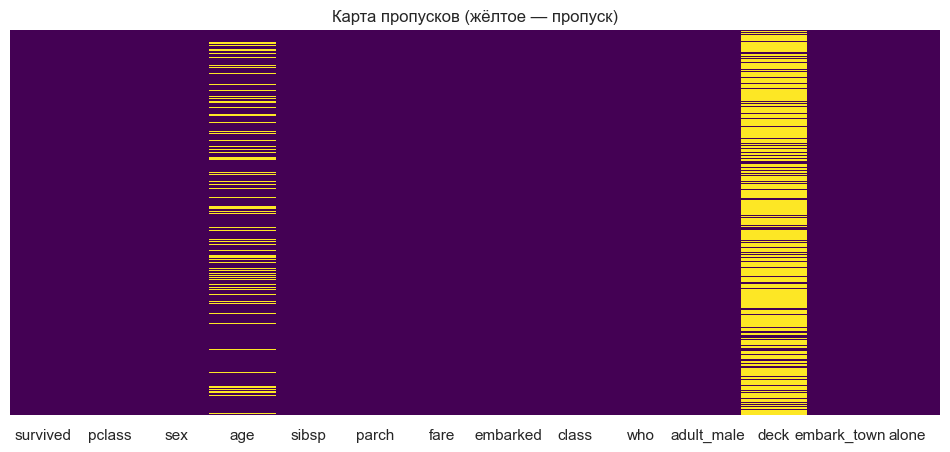

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Карта пропусков (жёлтое — пропуск)')
plt.show()

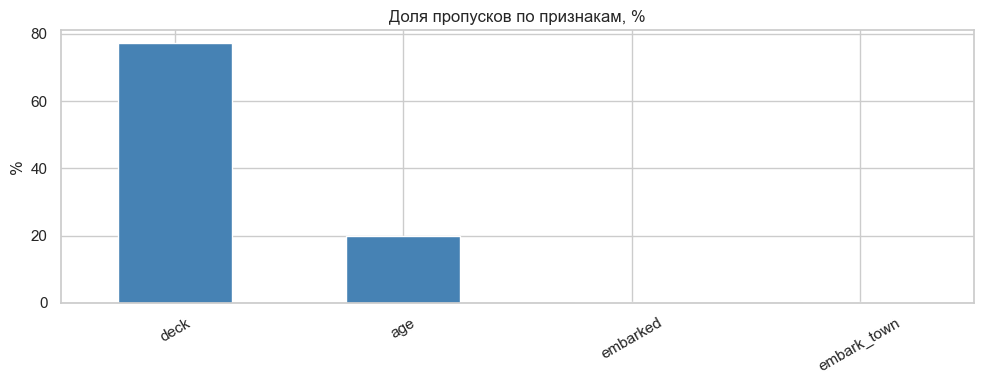

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_summary[missing_summary['Пропусков'] > 0]['Доля, %'].plot.bar(ax=ax, color='steelblue')
ax.set_title('Доля пропусков по признакам, %')
ax.set_ylabel('%')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Наблюдения:**

* `deck` отсутствует более чем у 77 % пассажиров — полная импьютация бессмысленна, лучше либо удалить столбец, либо рассматривать пропуск как отдельную категорию «неизвестно».
* `age` отсутствует примерно у 20 % — это умеренный пропуск, подходящий для статистической импьютации.
* `embarked` / `embark_town` отсутствуют у пары наблюдений — можно либо удалить эти строки, либо заполнить модой.

### 2.2. Удаление пропусков

Простейший способ — `dropna`. Полезно для оценки «дешёвой» обработки, однако теряем большую часть данных, если в данных хотя бы один сильно пропущенный признак.

In [8]:
df_dropall_rows = df.dropna()
df_dropall_cols = df.dropna(axis=1)
print('Удаление строк со всеми NaN:', df_dropall_rows.shape)
print('Удаление столбцов с NaN:    ', df_dropall_cols.shape)

Удаление строк со всеми NaN: (182, 14)
Удаление столбцов с NaN:     (891, 10)


Видно, что построчное удаление оставляет только ~180 наблюдений из 891 — потери чрезмерны из-за высокой доли пропусков в `deck`. Удаление столбцов лишает датасет полезных признаков (`age`, `embarked`). На практике это означает, что нужна более «умная» стратегия.

### 2.3. Заполнение средним и медианой (вручную через pandas)

Для числовых признаков заполним `age` медианой и средним и сравним распределения.

In [9]:
age_orig = df['age'].copy()
age_mean = df['age'].fillna(df['age'].mean())
age_median = df['age'].fillna(df['age'].median())

summary = pd.DataFrame({
    'исходный': age_orig.describe(),
    'mean-imputed': age_mean.describe(),
    'median-imputed': age_median.describe(),
})
summary

,исходный,mean-imputed,median-imputed
count,714.000,891.000,891.000
mean,29.699,29.699,29.362
std,14.526,13.002,13.020
min,0.420,0.420,0.420
25%,20.125,22.000,22.000
50%,28.000,29.699,28.000
75%,38.000,35.000,35.000
max,80.000,80.000,80.000


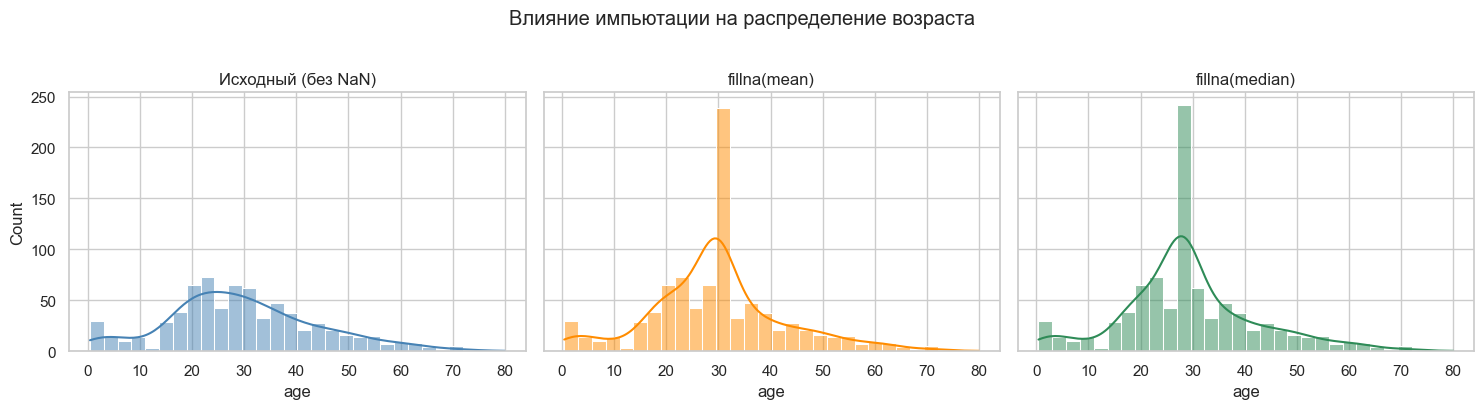

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, data, title, color in zip(
    axes,
    [age_orig.dropna(), age_mean, age_median],
    ['Исходный (без NaN)', 'fillna(mean)', 'fillna(median)'],
    ['steelblue', 'darkorange', 'seagreen'],
):
    sns.histplot(data, bins=30, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('age')
fig.suptitle('Влияние импьютации на распределение возраста', y=1.02)
fig.tight_layout()
plt.show()

Заметно появление характерного «пика» в районе среднего/медианы — это побочный эффект статистической импьютации: дисперсия признака сокращается, а форма распределения искажается.

### 2.4. `SimpleImputer` из scikit-learn

`SimpleImputer` универсален: подходит и для числовых (стратегии `mean`, `median`), и для категориальных признаков (`most_frequent`, `constant`).

In [11]:
num_cols = ['age', 'fare', 'sibsp', 'parch']
cat_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alone', 'adult_male']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_si = df.copy()
df_si[num_cols] = num_imputer.fit_transform(df_si[num_cols])
df_si[cat_cols] = cat_imputer.fit_transform(df_si[cat_cols])

print('Пропусков после SimpleImputer:', int(df_si.isna().sum().sum()))
df_si.head()

Пропусков после SimpleImputer: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000,1.000,0.000,7.250,S,Third,man,True,C,Southampton,False
1,1,1,female,38.000,1.000,0.000,71.283,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000,0.000,0.000,7.925,S,Third,woman,False,C,Southampton,True
3,1,1,female,35.000,1.000,0.000,53.100,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000,0.000,0.000,8.050,S,Third,man,True,C,Southampton,True


Альтернативный приём для категориального признака с большим числом пропусков — заполнение специальной меткой `'unknown'`. Это сохраняет информацию о самом факте пропуска как о признаке.

In [12]:
deck_imp = SimpleImputer(strategy='constant', fill_value='unknown')
deck_filled = pd.Series(deck_imp.fit_transform(df[['deck']]).ravel(), name='deck')
deck_filled.value_counts(dropna=False)

deck
unknown    688
C           59
B           47
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64

### 2.5. `KNNImputer` — импьютация по соседям

`KNNImputer` для каждого пропуска подбирает значение по ближайшим соседям в пространстве остальных числовых признаков. Это сохраняет дисперсию признака лучше, чем заполнение средним.

In [13]:
knn_imp = KNNImputer(n_neighbors=5)
age_knn = pd.Series(
    knn_imp.fit_transform(df[num_cols])[:, 0],
    name='age',
)

compare = pd.DataFrame({
    'исходный (без NaN)': age_orig.dropna().describe(),
    'median': age_median.describe(),
    'KNNImputer': age_knn.describe(),
})
compare

,исходный (без NaN),median,KNNImputer
count,714.000,891.000,891.000
mean,29.699,29.362,30.156
std,14.526,13.020,13.499
min,0.420,0.420,0.420
25%,20.125,22.000,22.000
50%,28.000,28.000,29.000
75%,38.000,35.000,38.000
max,80.000,80.000,80.000


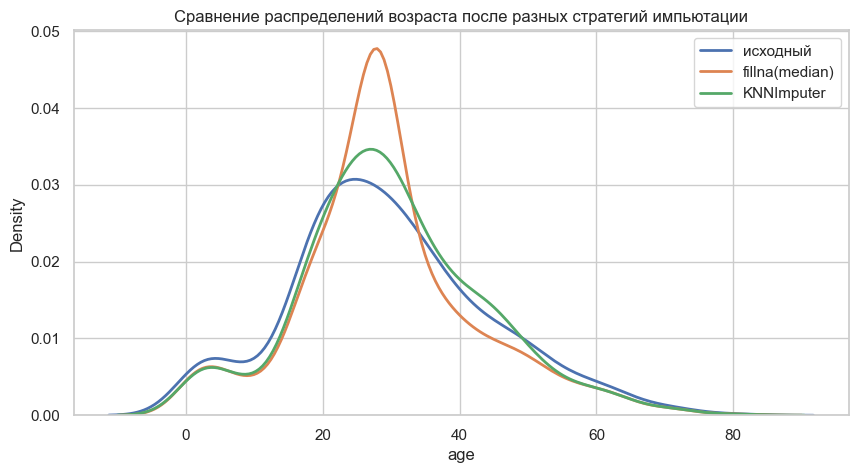

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(age_orig.dropna(), label='исходный', linewidth=2, ax=ax)
sns.kdeplot(age_median, label='fillna(median)', linewidth=2, ax=ax)
sns.kdeplot(age_knn, label='KNNImputer', linewidth=2, ax=ax)
ax.set_title('Сравнение распределений возраста после разных стратегий импьютации')
ax.set_xlabel('age')
ax.legend()
plt.show()

Распределение `age` после `KNNImputer` ближе к исходному, чем после заполнения медианой — нет резкого пика и сохраняется форма хвостов.

## 3. Кодирование категориальных признаков

Для дальнейшей работы возьмём датасет, в котором уже заполнены пропуски — `df_si`.

### 3.1. `LabelEncoder`

`LabelEncoder` назначает каждой категории уникальное число. Подходит **только для целевой переменной** или для порядковых признаков, поскольку для номинальных он вводит искусственный порядок.

In [15]:
le = LabelEncoder()
sex_encoded = le.fit_transform(df_si['sex'])
print('Классы:', list(le.classes_))
pd.DataFrame({'sex': df_si['sex'], 'sex_le': sex_encoded}).head()

Классы: ['female', 'male']


,sex,sex_le
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


### 3.2. `OrdinalEncoder`

`OrdinalEncoder` — тот же подход, но рассчитан на матрицу признаков (а не отдельный столбец) и интегрируется в `Pipeline`. Подходит для упорядоченных категорий (например, `class` имеет естественный порядок 'First' > 'Second' > 'Third').

In [16]:
ord_enc = OrdinalEncoder(categories=[['Third', 'Second', 'First']])
class_encoded = ord_enc.fit_transform(df_si[['class']]).ravel()
pd.DataFrame({'class': df_si['class'].astype(str), 'class_ord': class_encoded}).drop_duplicates()

,class,class_ord
0,Third,0.000
1,First,2.000
9,Second,1.000


### 3.3. `OneHotEncoder` (sklearn)

Для номинальных признаков предпочтителен one-hot — каждой категории сопоставляется отдельный столбец 0/1. Для борьбы с мультиколлинеарностью в линейных моделях часто используют `drop='first'`.

In [17]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
embarked_ohe = ohe.fit_transform(df_si[['embarked']])
ohe_df = pd.DataFrame(embarked_ohe, columns=ohe.get_feature_names_out(['embarked']))
ohe_df.head()

,embarked_C,embarked_Q,embarked_S
0,0.000,0.000,1.000
1,1.000,0.000,0.000
2,0.000,0.000,1.000
3,0.000,0.000,1.000
4,0.000,0.000,1.000


In [18]:
ohe_drop = OneHotEncoder(sparse_output=False, drop='first')
embarked_ohe_drop = ohe_drop.fit_transform(df_si[['embarked']])
pd.DataFrame(embarked_ohe_drop, columns=ohe_drop.get_feature_names_out(['embarked'])).head()

,embarked_Q,embarked_S
0,0.000,1.000
1,0.000,0.000
2,0.000,1.000
3,0.000,1.000
4,0.000,1.000


### 3.4. `pd.get_dummies`

Эквивалент one-hot, но возвращает сразу `DataFrame`. Удобен для быстрого EDA, однако не запоминает «обученный» словарь категорий — поэтому в продакшен-конвейерах безопаснее использовать sklearn-овский `OneHotEncoder`.

In [19]:
df_dum = pd.get_dummies(
    df_si[['sex', 'embarked', 'who']],
    prefix=['sex', 'embarked', 'who'],
    drop_first=False,
)
df_dum.head()

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,False,True,False,False,True,False,True,False
1,True,False,True,False,False,False,False,True
2,True,False,False,False,True,False,False,True
3,True,False,False,False,True,False,False,True
4,False,True,False,False,True,False,True,False


### 3.5. Частотное (frequency) кодирование

При большом числе уникальных значений (high-cardinality) one-hot становится неудобным. Альтернатива — кодировать категории частотой их встречаемости. Применим этот приём к `deck`.

In [20]:
freq_map = df_si['deck'].value_counts(normalize=True).to_dict()
deck_freq = df_si['deck'].map(freq_map)
pd.DataFrame({'deck': df_si['deck'].astype(str), 'deck_freq': deck_freq}).drop_duplicates().sort_values('deck_freq', ascending=False)

,deck,deck_freq
0,C,0.838
31,B,0.053
21,D,0.037
6,E,0.036
23,A,0.017
66,F,0.015
10,G,0.004


### 3.6. Целевое (target) кодирование

Категории заменяются средним значением целевой переменной в этой категории. Хорошо работает для high-cardinality признаков, но при неосторожном применении приводит к утечке данных — на практике используется в связке с кросс-валидацией.

In [21]:
target_map = df_si.groupby('deck')[TARGET].mean().to_dict()
deck_target = df_si['deck'].map(target_map)
pd.DataFrame({'deck': df_si['deck'].astype(str), 'survival_rate': deck_target}).drop_duplicates().sort_values('survival_rate', ascending=False)

,deck,survival_rate
21,D,0.758
6,E,0.750
31,B,0.745
66,F,0.615
10,G,0.500
23,A,0.467
0,C,0.323


## 4. Масштабирование числовых данных

Линейные модели, kNN, SVM и нейронные сети чувствительны к масштабу признаков. Сравним четыре способа масштабирования на признаках `age` и `fare` — они особенно показательны, поскольку `fare` сильно правосторонне асимметричен и содержит выбросы.

In [22]:
df_si[['age', 'fare', 'sibsp', 'parch']].describe()

,age,fare,sibsp,parch
count,891.000,891.000,891.000,891.000
mean,29.362,32.204,0.523,0.382
std,13.020,49.693,1.103,0.806
min,0.420,0.000,0.000,0.000
25%,22.000,7.910,0.000,0.000
50%,28.000,14.454,0.000,0.000
75%,35.000,31.000,1.000,0.000
max,80.000,512.329,8.000,6.000


In [23]:
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
}

scaled_frames = {}
for name, sc in scalers.items():
    arr = sc.fit_transform(df_si[['age', 'fare']])
    scaled_frames[name] = pd.DataFrame(arr, columns=['age', 'fare'])

summary = pd.concat(
    {name: f.describe().loc[['mean', 'std', 'min', 'max']] for name, f in scaled_frames.items()},
    axis=1,
)
summary.round(3)

StandardScaler        MinMaxScaler       RobustScaler         \
                age   fare          age  fare          age   fare   
mean          0.000  0.000        0.364 0.063        0.105  0.769   
std           1.001  1.001        0.164 0.097        1.002  2.152   
min          -2.224 -0.648        0.000 0.000       -2.122 -0.626   
max           3.892  9.667        1.000 1.000        4.000 21.563   

     MaxAbsScaler        
              age  fare  
mean        0.367 0.063  
std         0.163 0.097  
min         0.005 0.000  
max         1.000 1.000

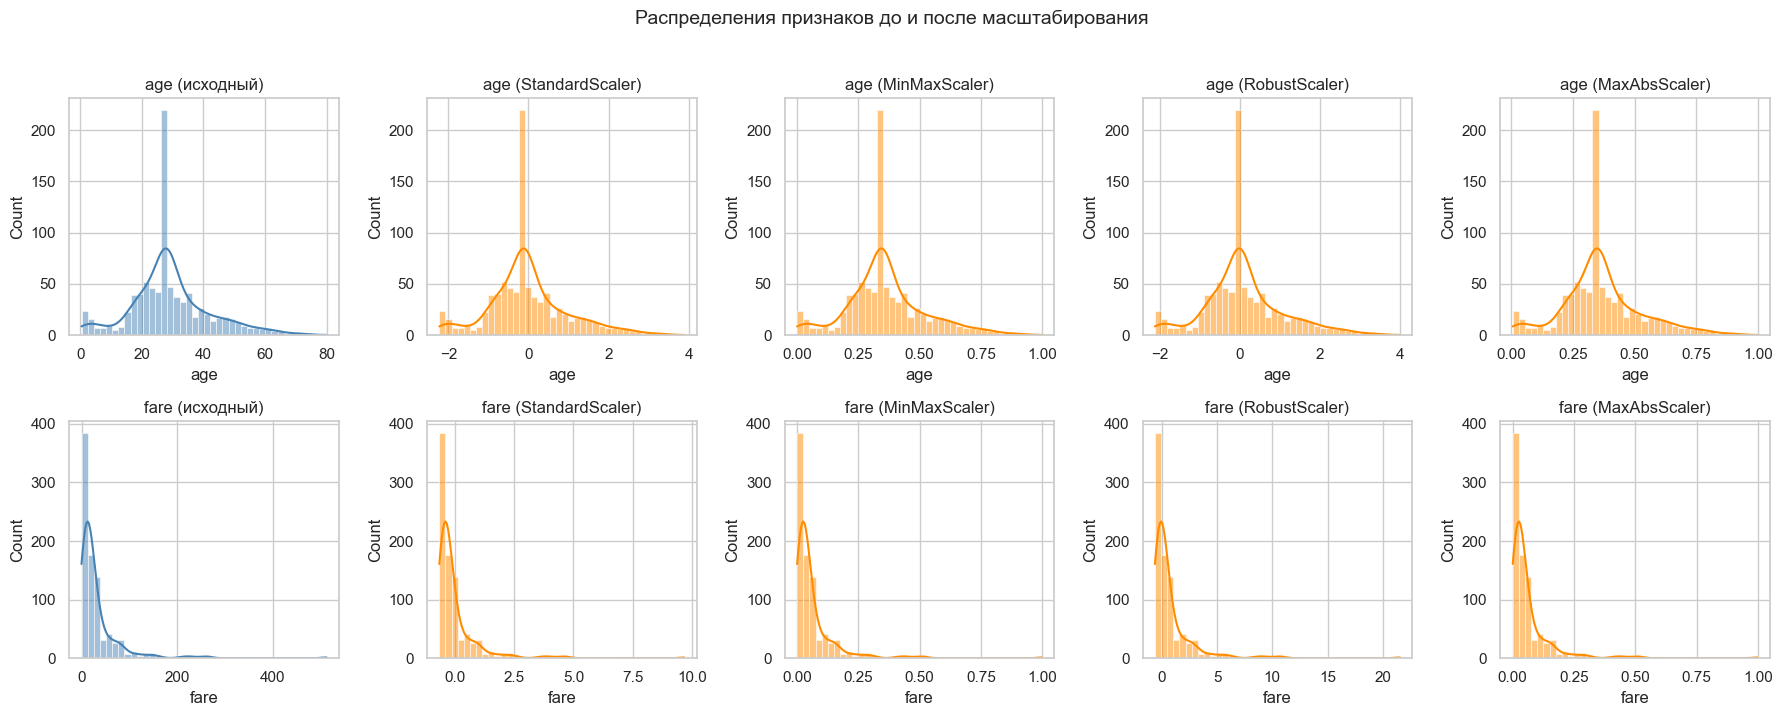

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for col_idx, col in enumerate(['age', 'fare']):
    sns.histplot(df_si[col], bins=40, kde=True, ax=axes[col_idx, 0], color='steelblue')
    axes[col_idx, 0].set_title(f'{col} (исходный)')
    for i, (name, frame) in enumerate(scaled_frames.items(), start=1):
        sns.histplot(frame[col], bins=40, kde=True, ax=axes[col_idx, i], color='darkorange')
        axes[col_idx, i].set_title(f'{col} ({name})')
fig.suptitle('Распределения признаков до и после масштабирования', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

/var/folders/hx/f48x7vtn6dvfrw9ff07pmv400000gp/T/ipykernel_9909/2190476002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison, x='scaler', y=col, ax=ax, palette='Set2')
/var/folders/hx/f48x7vtn6dvfrw9ff07pmv400000gp/T/ipykernel_9909/2190476002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison, x='scaler', y=col, ax=ax, palette='Set2')


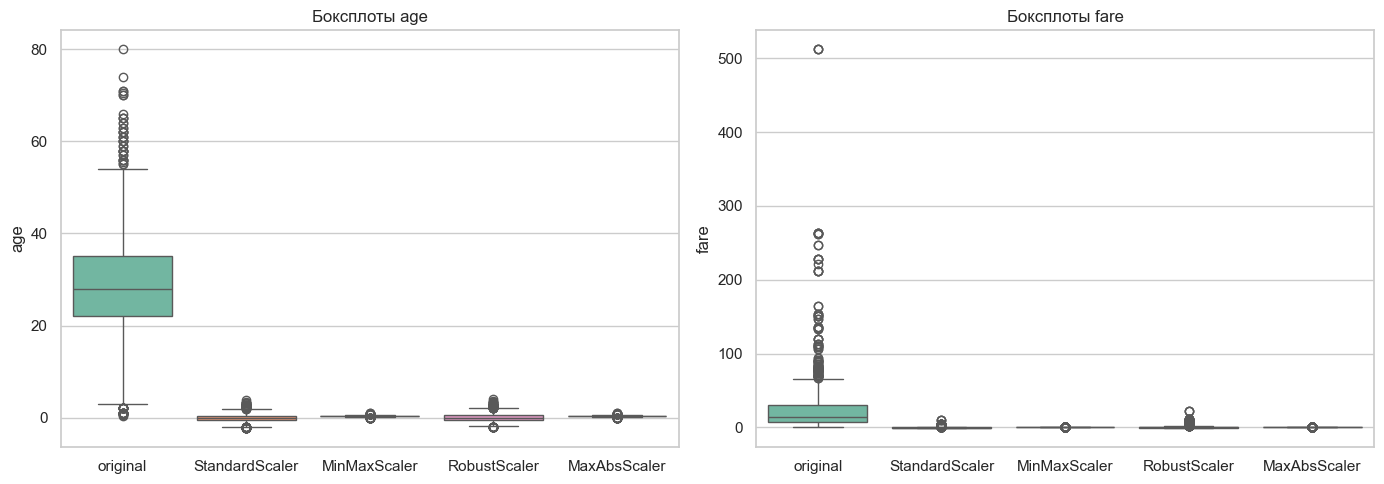

In [25]:
comparison = pd.concat(
    [df_si[['age', 'fare']].assign(scaler='original')]
    + [f.assign(scaler=name) for name, f in scaled_frames.items()],
    ignore_index=True,
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['age', 'fare']):
    sns.boxplot(data=comparison, x='scaler', y=col, ax=ax, palette='Set2')
    ax.set_title(f'Боксплоты {col}')
    ax.set_xlabel('')
fig.tight_layout()
plt.show()

**Выводы по масштабированию:**

* `StandardScaler` приводит признаки к нулевому среднему и единичной дисперсии; форма распределения сохраняется, но выбросы остаются «дальше» от центра.
* `MinMaxScaler` сжимает значения в диапазон [0, 1]; чувствителен к выбросам (например, `fare` за счёт максимума ~512 имеет всю массу наблюдений сжатой к нулю).
* `RobustScaler` использует медиану и IQR, поэтому устойчив к выбросам — лучше всего работает с `fare`.
* `MaxAbsScaler` делит на максимум по модулю; полезен для разреженных данных, но как и `MinMaxScaler` чувствителен к выбросам.

Форма исходного распределения ни один из масштабировщиков не меняет; для изменения формы нужны нелинейные преобразования (`PowerTransformer`, логарифм).

## 5. Итоговый предобрабатывающий конвейер

Соберём в единый sklearn-`Pipeline` следующие шаги:

1. **Числовые признаки** — `KNNImputer` + `StandardScaler`.
2. **Категориальные с малой кардинальностью** — `SimpleImputer(most_frequent)` + `OneHotEncoder`.
3. **`deck`** (высокая кардинальность + много пропусков) — `SimpleImputer(constant='unknown')` + `OneHotEncoder`.

Применим конвейер ко всему датасету и убедимся, что на выходе получаем матрицу признаков без пропусков и в едином масштабе.

In [26]:
df_p = df_raw.drop(columns=['alive']).copy()
y = df_p[TARGET]
X = df_p.drop(columns=[TARGET])

num_features = ['age', 'fare', 'sibsp', 'parch', 'pclass']
low_card_cat = ['sex', 'embarked', 'class', 'who', 'embark_town', 'alone', 'adult_male']
high_card_cat = ['deck']

num_pipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
])

low_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

high_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('low_cat', low_card_pipe, low_card_cat),
    ('high_cat', high_card_pipe, high_card_cat),
])

preprocessor

,transformers,"[('num', ...), ('low_cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'


In [27]:
X_prepared = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_prepared_df = pd.DataFrame(X_prepared, columns=feature_names)
print('Размер исходной матрицы:        ', X.shape)
print('Размер после трансформации:     ', X_prepared_df.shape)
print('Пропусков на выходе:            ', int(X_prepared_df.isna().sum().sum()))
X_prepared_df.head()

Размер исходной матрицы:         (891, 13)
Размер после трансформации:      (891, 31)
Пропусков на выходе:             0


,num__age,num__fare,num__sibsp,num__parch,num__pclass,low_cat__sex_female,low_cat__sex_male,low_cat__embarked_C,low_cat__embarked_Q,low_cat__embarked_S,...,low_cat__adult_male_False,low_cat__adult_male_True,high_cat__deck_A,high_cat__deck_B,high_cat__deck_C,high_cat__deck_D,high_cat__deck_E,high_cat__deck_F,high_cat__deck_G,high_cat__deck_unknown
0,-0.592,-0.502,0.433,-0.474,0.827,0.000,1.000,0.000,0.000,1.000,...,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
1,0.598,0.787,0.433,-0.474,-1.566,1.000,0.000,1.000,0.000,0.000,...,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
2,-0.294,-0.489,-0.475,-0.474,0.827,1.000,0.000,0.000,0.000,1.000,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
3,0.375,0.421,0.433,-0.474,-1.566,1.000,0.000,0.000,0.000,1.000,...,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
4,0.375,-0.486,-0.475,-0.474,0.827,0.000,1.000,0.000,0.000,1.000,...,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000


In [28]:
num_view = X_prepared_df[[c for c in X_prepared_df.columns if c.startswith('num__')]]
num_view.describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
num__age,-0.000,1.001,-2.196,3.722
num__fare,0.000,1.001,-0.648,9.667
num__sibsp,0.000,1.001,-0.475,6.784
num__parch,0.000,1.001,-0.474,6.974
num__pclass,-0.000,1.001,-1.566,0.827


Числовые столбцы после конвейера имеют среднее, близкое к 0, и стандартное отклонение, близкое к 1 — что и ожидалось от `StandardScaler`. Все пропуски устранены, категориальные признаки представлены one-hot матрицами.

Полученный `ColumnTransformer` можно подключать дальше в `Pipeline` с любой sklearn-моделью (`LogisticRegression`, `RandomForestClassifier` и т. д.).

## Итоги

В работе на датасете **Titanic** (891 наблюдение, 14 признаков, бинарная классификация) рассмотрены три блока предобработки:

1. **Пропуски.** Изучены: удаление (`dropna`), ручная импьютация `fillna(mean/median)`, `SimpleImputer` (`median` / `most_frequent` / `constant='unknown'`) и `KNNImputer`. Показано, что `KNNImputer` сохраняет форму исходного распределения `age` лучше, чем заполнение медианой, а удаление приводит к потере ~80 % данных из-за высокой доли пропусков в `deck`.
2. **Кодирование категорий.** Применены `LabelEncoder`, `OrdinalEncoder` (для порядковой `class`), `OneHotEncoder` (с `drop='first'` и без), `pd.get_dummies`, а также частотное и целевое кодирование `deck`. Обсуждены границы применимости каждого метода.
3. **Масштабирование.** Сопоставлены `StandardScaler`, `MinMaxScaler`, `RobustScaler` и `MaxAbsScaler` на признаках `age` и `fare`. На сильно асимметричном `fare` явное преимущество показал `RobustScaler` — он устойчив к выбросам, ограничивающим эффективность `MinMaxScaler`.
4. Финальный **`ColumnTransformer + Pipeline`** объединяет все три этапа и формирует чистую численную матрицу признаков, готовую для последующего обучения модели.